#### Multidimensional Monte Carlo Integration #########

We want to solve the following high-dimensional integral 

$$ I = \int_{[0,1]^d} \exp\left(-\left[\sum_{i=1}^d x_i - \frac{d}{2}\right]^2\right) \, dx $$

Using Monte Carlo with Uniform Sampling: 

$$\hat{I}_N \approx \frac{1}{N} \sum_{i=1}^N \exp\left(-\left[\sum_{j=1}^d (X_i)_j-\frac{d}{2}\right]^2\right)
$$

Then, we will use Reimann Sum, and see how Monte Carlo is more efficient!!

$$d= 20$$

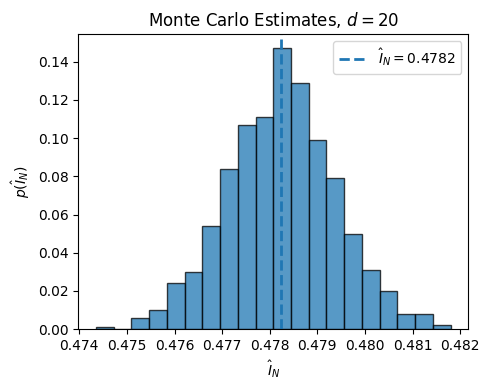

In [ ]:
########################### First MC method #########################

import numpy as np 
import matplotlib.pyplot as plt

# parameters 
dimension = 20
num_samples = int(1e5)
num_experiments = int(1e3)

estiamted_integral = np.zeros((num_experiments, 1))

for experiment in range(num_experiments):
    
    # generate uniform samples
    samples = np.random.uniform(0, 1, (dimension, 1, num_samples))
    
    sample_sums = np.sum(samples[:, 0, :], axis=0) ### summing over dimension
    
    estiamted_integral[experiment] = np.mean(np.exp(-(sample_sums - dimension/2)**2))



#plot 
plt.figure(figsize=(5, 4))

plt.hist(
    estiamted_integral.flatten(),
    bins=20,
    weights=np.ones(num_experiments) / num_experiments,
    alpha=0.75,
    edgecolor="black"
)

plt.axvline(
    np.mean(estiamted_integral),
    linestyle="--",
    linewidth=2,
    label=rf"$\hat{{I}}_N = {np.mean(estiamted_integral):.4f}$"
)

plt.xlabel(r"$\hat{I}_N$")
plt.ylabel(r"$p(\hat{I}_N)$")
plt.title(rf"Monte Carlo Estimates, $d = {dimension}$")

plt.legend()
plt.tight_layout()
plt.show()

#### Multidimensional Reimann Sum Approximation #########

We want to solve the following high-dimensional integral 

$$ I = \int_{[0,1]^d} \exp\left(-\left[\sum_{i=1}^d x_i - \frac{d}{2}\right]^2\right) \, dx $$

Using right-endpoint: 

$$\hat{I}_N \approx \left(\frac{1}{k}\right)^d \sum_{i_1=1}^k \dots \sum_{i_d=1}^k \exp\left(-\left[\sum_{j=1}^d (x_{i_j})-\frac{d}{2}\right]^2\right),
$$

where $x_{i_j} = {i_j}/k$. $k$ here refers to the number of points per dimension. 

Notice how many summations we have!!! We have $d$ summations
$$d= 20$$

Right-endpoint Riemann estimate, k = 2: 0.000315
Midpoint Riemann estimate,       k = 2: 0.531079
Monte Carlo mean estimate:             0.478245
Monte Carlo std over experiments:      0.001136


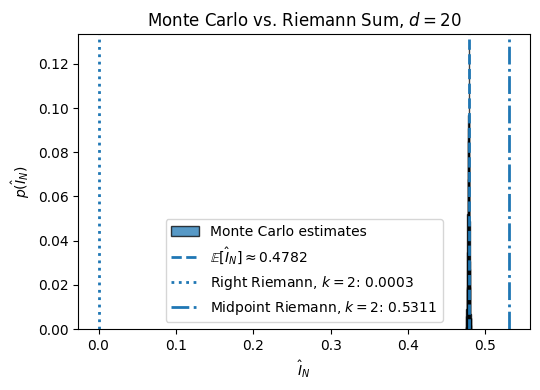

In [156]:
############################################## Reimann Sum Approximation #####################
from itertools import product


def integrand(x, dimension):
    return np.exp(-(np.sum(x) - dimension / 2)**2)

def riemann_sum(points_per_dimension, dimension=20, rule="midpoint"):
    k = points_per_dimension

    if rule == "right":
        grid_points = np.arange(1, k + 1) / k
    elif rule == "midpoint":
        grid_points = (np.arange(k) + 0.5) / k
    else:
        raise ValueError("rule must be either 'right' or 'midpoint'")

    total_points = k**dimension
    estimate = 0.0

    for coordinates in product(grid_points, repeat=dimension):
        estimate += integrand(np.array(coordinates), dimension)

    return estimate / total_points



dimension=20
points_per_dimension=2 # poi


# Riemann estimates
I_right = riemann_sum(points_per_dimension, dimension, rule="right")
I_mid = riemann_sum(points_per_dimension, dimension, rule="midpoint")



print(f"Right-endpoint Riemann estimate, k = {points_per_dimension}: {I_right:.6f}")
print(f"Midpoint Riemann estimate,       k = {points_per_dimension}: {I_mid:.6f}")
print(f"Monte Carlo mean estimate:             {np.mean(estiamted_integral):.6f}")
print(f"Monte Carlo std over experiments:      {np.std(estiamted_integral):.6f}")

plt.figure(figsize=(5.5, 4))

plt.hist(
    estiamted_integral,
    bins=25,
    weights=np.ones(num_experiments) / num_experiments,
    alpha=0.75,
    edgecolor="black",
    label=r"Monte Carlo estimates"
)

plt.axvline(
    np.mean(estiamted_integral),
    linestyle="--",
    linewidth=2,
    label=rf"$\mathbb{{E}}[\hat I_N] \approx {np.mean(estiamted_integral):.4f}$"
)

plt.axvline(
    I_right,
    linestyle=":",
    linewidth=2,
    label=rf"Right Riemann, $k={k}$: ${I_right:.4f}$"
)

plt.axvline(
    I_mid,
    linestyle="-.",
    linewidth=2,
    label=rf"Midpoint Riemann, $k={k}$: ${I_mid:.4f}$"
)

plt.xlabel(r"$\hat I_N$")
plt.ylabel(r"$p(\hat I_N)$")
plt.title(rf"Monte Carlo vs. Riemann Sum, $d={dimension}$")

plt.legend()
plt.tight_layout()
plt.show()